# Лабораторная работа №1. Линейная регрессия и факторный анализ
### Цель работы
Изучение основ линейной регрессии, построение простейших моделей регрессии, проведение обучения модели на реальных данных и оценка её качество

### Описание датасета 
diamonds.csv - содержит информацию о характеристиках и ценах на бриллианты.   
Датасет содержит 53 940 строк и 10 признаков столбцов  
Столбцы в датасете:  
`carat` - вес брилллианта  
`cut` - качество огранки  
`color` - цвет бриллианта  
`clarity` - чистота бриллианта   
`depth` - общая глубина  
`table` -  ширина верхней площадки относительно самой широкой точки  
`x` - длина в мм  
`y` - ширина в мм  
`z`  - глубина в мм  
Целевая переменная - `price`

### Импорты библиотек

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, make_scorer
from statsmodels.stats.outliers_influence import variance_inflation_factor

### Первичный анализ

Загрузка датасета

In [21]:
df = pd.read_csv('diamonds.csv')
print("Размер датасета:", df.shape)


Размер датасета: (53940, 10)


Проверка пропусков 

In [22]:
print("Количество пропусков:")
print(df.isnull().sum())

Количество пропусков:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64


In [23]:
zero_dimensions = df[(df['x'] == 0) | (df['y'] == 0) | (df['z'] == 0)]
print(f"\nКоличество строк с нулевыми размерами алмазов (x, y, z): {len(zero_dimensions)}")

df = df[(df['x'] > 0) & (df['y'] > 0) & (df['z'] > 0)]
print(f"Размер датасета после удаления аномалий: {df.shape}")



Количество строк с нулевыми размерами алмазов (x, y, z): 20
Размер датасета после удаления аномалий: (53920, 10)


### Визуализация распределений и кодирование признаков

Целевая переменная 

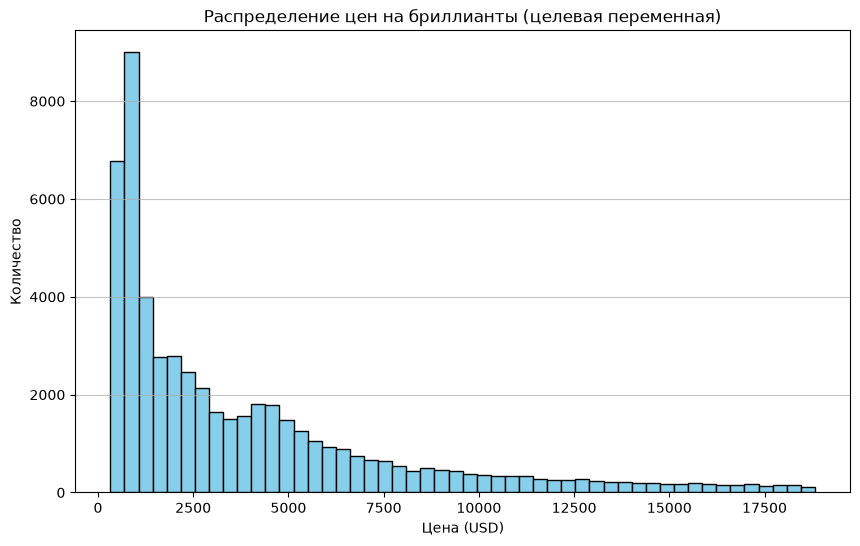

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(df['price'], bins=50, color='skyblue', edgecolor='black')
plt.title('Распределение цен на бриллианты (целевая переменная)')
plt.xlabel('Цена (USD)')
plt.ylabel('Количество')
plt.grid(axis='y', alpha=0.75)
plt.show()

Визуализация распределения числовых признаков

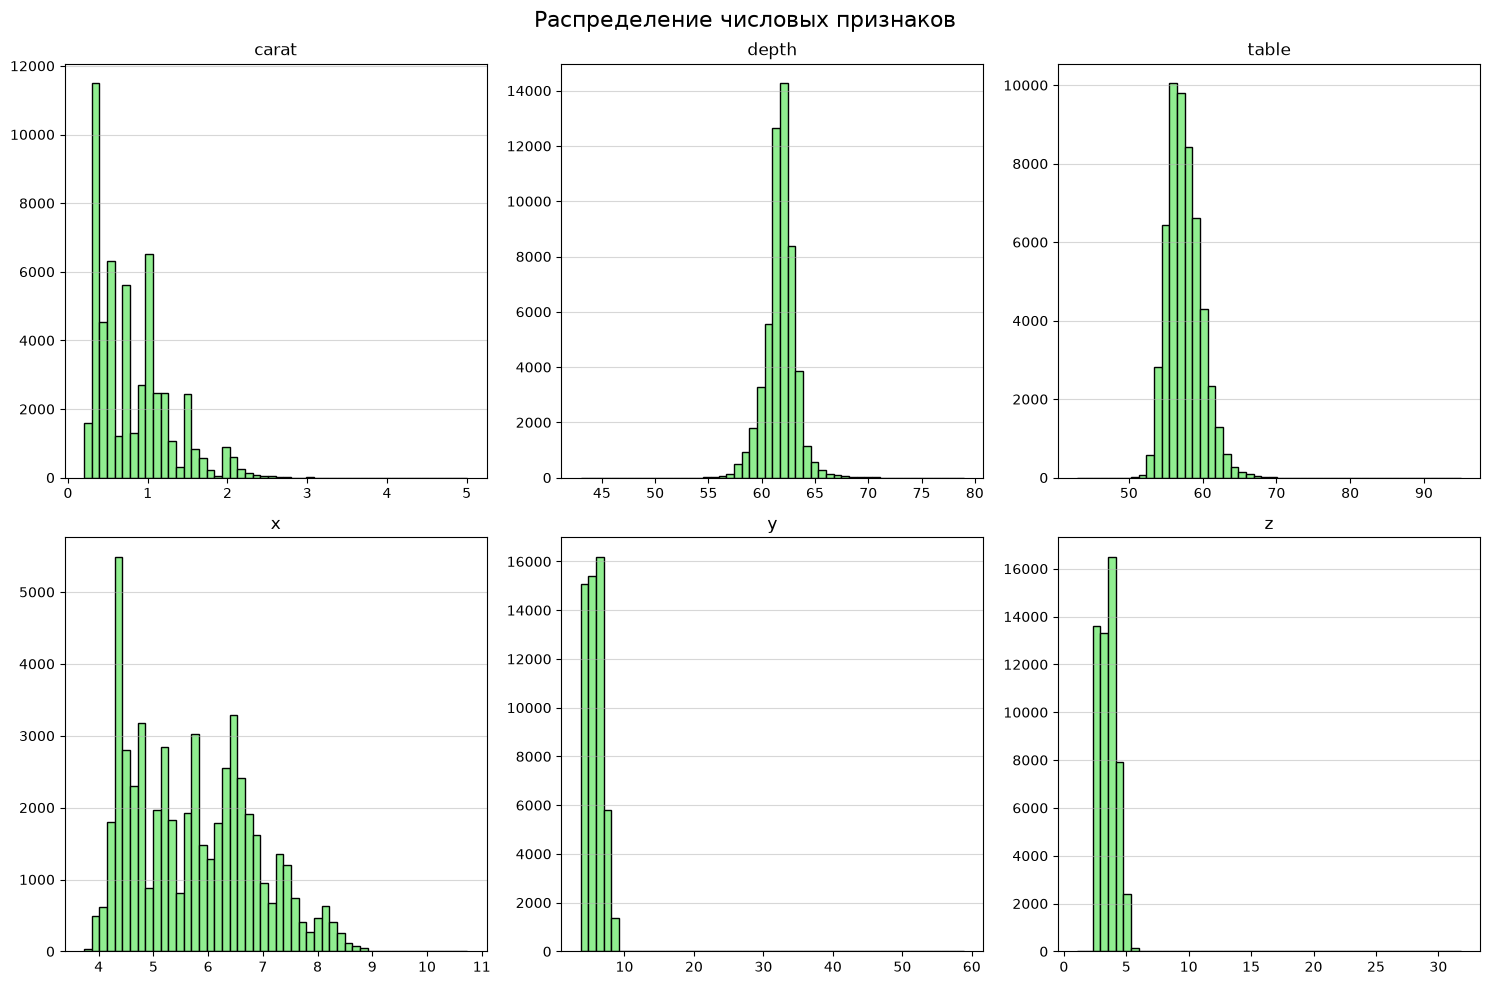

In [ ]:
numeric_features = ['carat', 'depth', 'table', 'x', 'y', 'z']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Распределение числовых признаков', fontsize=16)

for i, col in enumerate(numeric_features):
    ax = axes[i//3, i%3]
    ax.hist(df[col], bins=50, color='lightgreen', edgecolor='black')
    ax.set_title(col)
    ax.grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.show()

Визуализация категориальных признаков

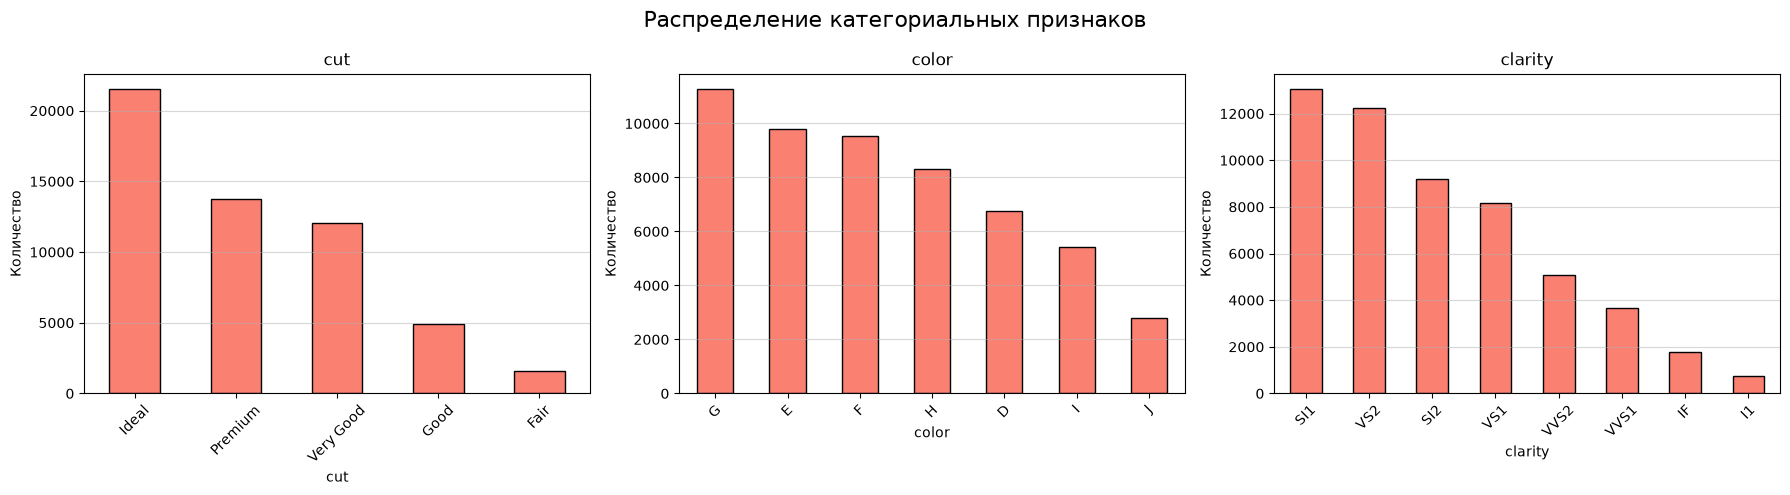

In [ ]:
categorical_features = ['cut', 'color', 'clarity']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Распределение категориальных признаков', fontsize=16)

for i, col in enumerate(categorical_features):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='salmon', edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_ylabel('Количество')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.show()